In [ ]:
# Import system libraries
import logging
import sys

# Import scientific libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import h5py

#%% First Simulation(That we can alter as needed)
from lisainstrument import Instrument#, SchedulerConfigParallel#, sim_result_file
from pytdi import Data
from pytdi.michelson import X2, Y2, Z2

from ldc.lisa.noise import get_noise_model
from ldc.waveform.waveform import HpHc

#Create an orbits file for equal arm length
from lisaorbits import EqualArmlengthOrbits
#from lisaconstants import MOSAS
#from lisaconstants.indexing import MOSAS
from lisaorbits import KeplerianOrbits
from scipy.signal import welch

#from lolipops.io import Sampling, TimeSeriesArray
#from lolipops.pipelines.utils import welch

logging.basicConfig(level=logging.INFO)

ModuleNotFoundError: No module named 'lolipops'

## goal is to simulate TTL and add it to the waveform manually first

In [14]:
sim_name = 'TTL_only_sim_1.h5'

In [ ]:
a_day = 24 * 3600  # s

orbits_t0 = 0.0  # s
orbits_dt = 5e5  # s
orbits_duration = 365 * a_day  # s
orbits_size = int(orbits_duration / orbits_dt)  # samples

orbits = KeplerianOrbits()
orbits.write("orbits.h5", t0=orbits_t0, dt=orbits_dt, size=orbits_size, mode="w")

INFO:lisaorbits.orbits:Initializing orbits (lisaorbit verion 2.4.2)
INFO:lisaorbits.orbits:Creating orbit file orbits.h5
INFO:lisaorbits.orbits:Closing orbit file orbits.h5


# TTL Coefficients

In [ ]:
'''
# Define slopes of linear TTL coefficients
ttl_coeff_slopes = {
    # Eta RX
    "c_12_eta_rx": -8.50134579731159e-10,
    "c_13_eta_rx": 4.52178067218007e-10,
    "c_23_eta_rx": -1.4137247677915e-09,
    "c_21_eta_rx": -5.24110763500375e-11,
    "c_31_eta_rx": -1.46974994600151e-09,
    "c_32_eta_rx": 1.45226028388893e-09,
    # Phi RX
    "c_12_phi_rx": -6.37175816526929e-10,
    "c_13_phi_rx": 3.4377708540783e-10,
    "c_23_phi_rx": 8.40743789721586e-10,
    "c_21_phi_rx": 1.09849290241514e-09,
    "c_31_phi_rx": -5.21352866703423e-10,
    "c_32_phi_rx": -1.37421077261788e-09,
    # Eta TX
    "c_12_eta_tx": 1.723846941339e-09,
    "c_13_eta_tx": 4.91581239005378e-10,
    "c_23_eta_tx": 1.47119977626962e-10,
    "c_21_eta_tx": 5.37520648543255e-10,
    "c_31_eta_tx": -7.72569409235369e-10,
    "c_32_eta_tx": 8.50769415703494e-10,
    # Phi TX
    "c_12_phi_tx": -5.7987570987987e-10,
    "c_13_phi_tx": -1.54246335938132e-09,
    "c_23_phi_tx": -8.76215809529001e-10,
    "c_21_phi_tx": 1.2784620062412e-09,
    "c_31_phi_tx": 1.55716703812013e-09,
    "c_32_phi_tx": -6.3720473590357e-10,
}
'''

ttl_coeffs = {
    # Eta RX
    "c_12_eta_rx": 2.3,#-0.00367766119873637,
    "c_13_eta_rx": 2.3,#-0.00306613516145773,
    "c_23_eta_rx": 2.3,#0.00406379191860704,
    "c_21_eta_rx": 2.3,#-0.00292577723420689,
    "c_31_eta_rx": 2.3,#0.00277194967621456,
    "c_32_eta_rx": 2.3,#-0.00369869832586783,
    # Phi RX
    "c_12_phi_rx": 2.3,#0.003778351983793,
    "c_13_phi_rx": 2.3,#0.00487385712667897,
    "c_23_phi_rx": 2.3,#0.00174769874388112,
    "c_21_phi_rx": 2.3,#-0.0019304854228092,
    "c_31_phi_rx": 2.3,#0.00357002815056497,
    "c_32_phi_rx": 2.3,#-0.00417893210240183,
    # Eta TX
    "c_12_eta_tx": 2.3,#0.00355682294436776,
    "c_13_eta_tx": 2.3,#0.0016380939705419,
    "c_23_eta_tx": 2.3,#-0.00117220980099441,
    "c_21_eta_tx": 2.3,#-0.00378694920673023,
    "c_31_eta_tx": 2.3,#0.00293420598270193,
    "c_32_eta_tx": 2.3,#-0.00466642014132255,
    # Phi TX
    "c_12_phi_tx": 2.3,#-0.00192846568588467,
    "c_13_phi_tx": 2.3,#0.00450805872044492,
    "c_23_phi_tx": 2.3,#-0.00468215111842327,
    "c_21_phi_tx": 2.3,#0.00429255732469105,
    "c_31_phi_tx": 2.3,#-0.00219602856834339,
    "c_32_phi_tx": 2.3,#-0.00107552757674203,
}

#set up for instrument file, ttl_coeffs is a function in simulation.ipynb that accounts for time varying coeffs, input is "c_ij_k_lx"
lisainstrument_ttl_coeffs = [
    # Local phis
    {
        "12": ttl_coeffs["c_12_phi_rx"],#ttl_coeffs[],
        "23": ttl_coeffs["c_23_phi_rx"],#ttl_coeffs[],
        "31": ttl_coeffs["c_31_phi_rx"],#ttl_coeffs[],
        "13": ttl_coeffs["c_13_phi_rx"],#ttl_coeffs[],
        "32": ttl_coeffs["c_32_phi_rx"],#ttl_coeffs[],
        "21": ttl_coeffs["c_21_phi_rx"],#ttl_coeffs[],
    },
    # Distant phis
    {
        "12": ttl_coeffs["c_12_phi_tx"],#ttl_coeffs[],
        "23": ttl_coeffs["c_23_phi_tx"],#ttl_coeffs[],
        "31": ttl_coeffs["c_31_phi_tx"],#ttl_coeffs[],
        "13": ttl_coeffs["c_13_phi_tx"],#ttl_coeffs[],
        "32": ttl_coeffs["c_32_phi_tx"],#ttl_coeffs[],
        "21": ttl_coeffs["c_21_phi_tx"],#ttl_coeffs[],
    },
    # Local etas
    {
        "12": ttl_coeffs["c_12_eta_rx"],#ttl_coeffs[],
        "23": ttl_coeffs["c_23_eta_rx"],#ttl_coeffs[],
        "31": ttl_coeffs["c_31_eta_rx"],#ttl_coeffs[],
        "13": ttl_coeffs["c_13_eta_rx"],#ttl_coeffs[],
        "32": ttl_coeffs["c_32_eta_rx"],#ttl_coeffs[],
        "21": ttl_coeffs["c_21_eta_rx"],#ttl_coeffs[],
    },
    # Distant etas
    {
        "12": ttl_coeffs["c_12_eta_tx"],#ttl_coeffs[],
        "23": ttl_coeffs["c_23_eta_tx"],#ttl_coeffs[],
        "31": ttl_coeffs["c_31_eta_tx"],#ttl_coeffs[],
        "13": ttl_coeffs["c_13_eta_tx"],#ttl_coeffs[],
        "32": ttl_coeffs["c_32_eta_tx"],#ttl_coeffs[],
        "21": ttl_coeffs["c_21_eta_tx"],#ttl_coeffs[],
    },
]

# Instrument simulation

In [ ]:
instru_t0 = orbits_t0 + 10  # s
instru_fs = 4  # Hz
instru_dt = 1 / instru_fs  # s
instru_duration = a_day  # s
instru_size = int(instru_duration * instru_fs)  # samples
instru = Instrument(size = instru_size,
                    orbits = 'orbits.h5', 
                    ttl_coeffs = lisainstrument_ttl_coeffs, 
                    #seed = 2030,
                    sc_angular_jitter_asds=(5.0e-9, 5.0e-9, 5.0e-9), 
                    mosa_angular_jitter_asds=(2.0e-9, 1.0e-9),
                    dws_asds=7e-8 / 335,
                    ) 
instru.disable_all_noises(excluding = ['angular-jitters'])

instru.simulate()

instru.write(sim_name, mode='w')

INFO:lisainstrument.instrument:Initializing instrumental simulation
INFO:lisainstrument.instrument:Computing measurement time vector (size=345600, dt=0.25)
INFO:lisainstrument.instrument:Computing physics time vector (size=1382400, dt=0.0625)
INFO:lisainstrument.instrument:Computing telemetry time vector (size=2, dt=86400.0)
INFO:lisainstrument.instrument:Using orbit file 'orbits.h5'
INFO:lisainstrument.instrument:Using pre-defined locking configuration 'N1-12'
INFO:lisainstrument.instrument:Designing antialiasing filter ('kaiser', 240, 1.1, 2.9)
INFO:lisainstrument.instrument:Starting simulation
INFO:lisainstrument.instrument:Generating clock noise
INFO:lisainstrument.instrument:Generating modulation noise
INFO:lisainstrument.instrument:Generating backlink noise
INFO:lisainstrument.instrument:Generating test-mass acceleration noise
INFO:lisainstrument.instrument:Generating ranging noise
INFO:lisainstrument.instrument:Generating OMS noise
INFO:lisainstrument.instrument:Generating DWS m

INFO:lisainstrument.instrument:Plotting beatnote frequency fluctuations
/Users/corinnekomlodi/Desktop/Robbie_UV/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


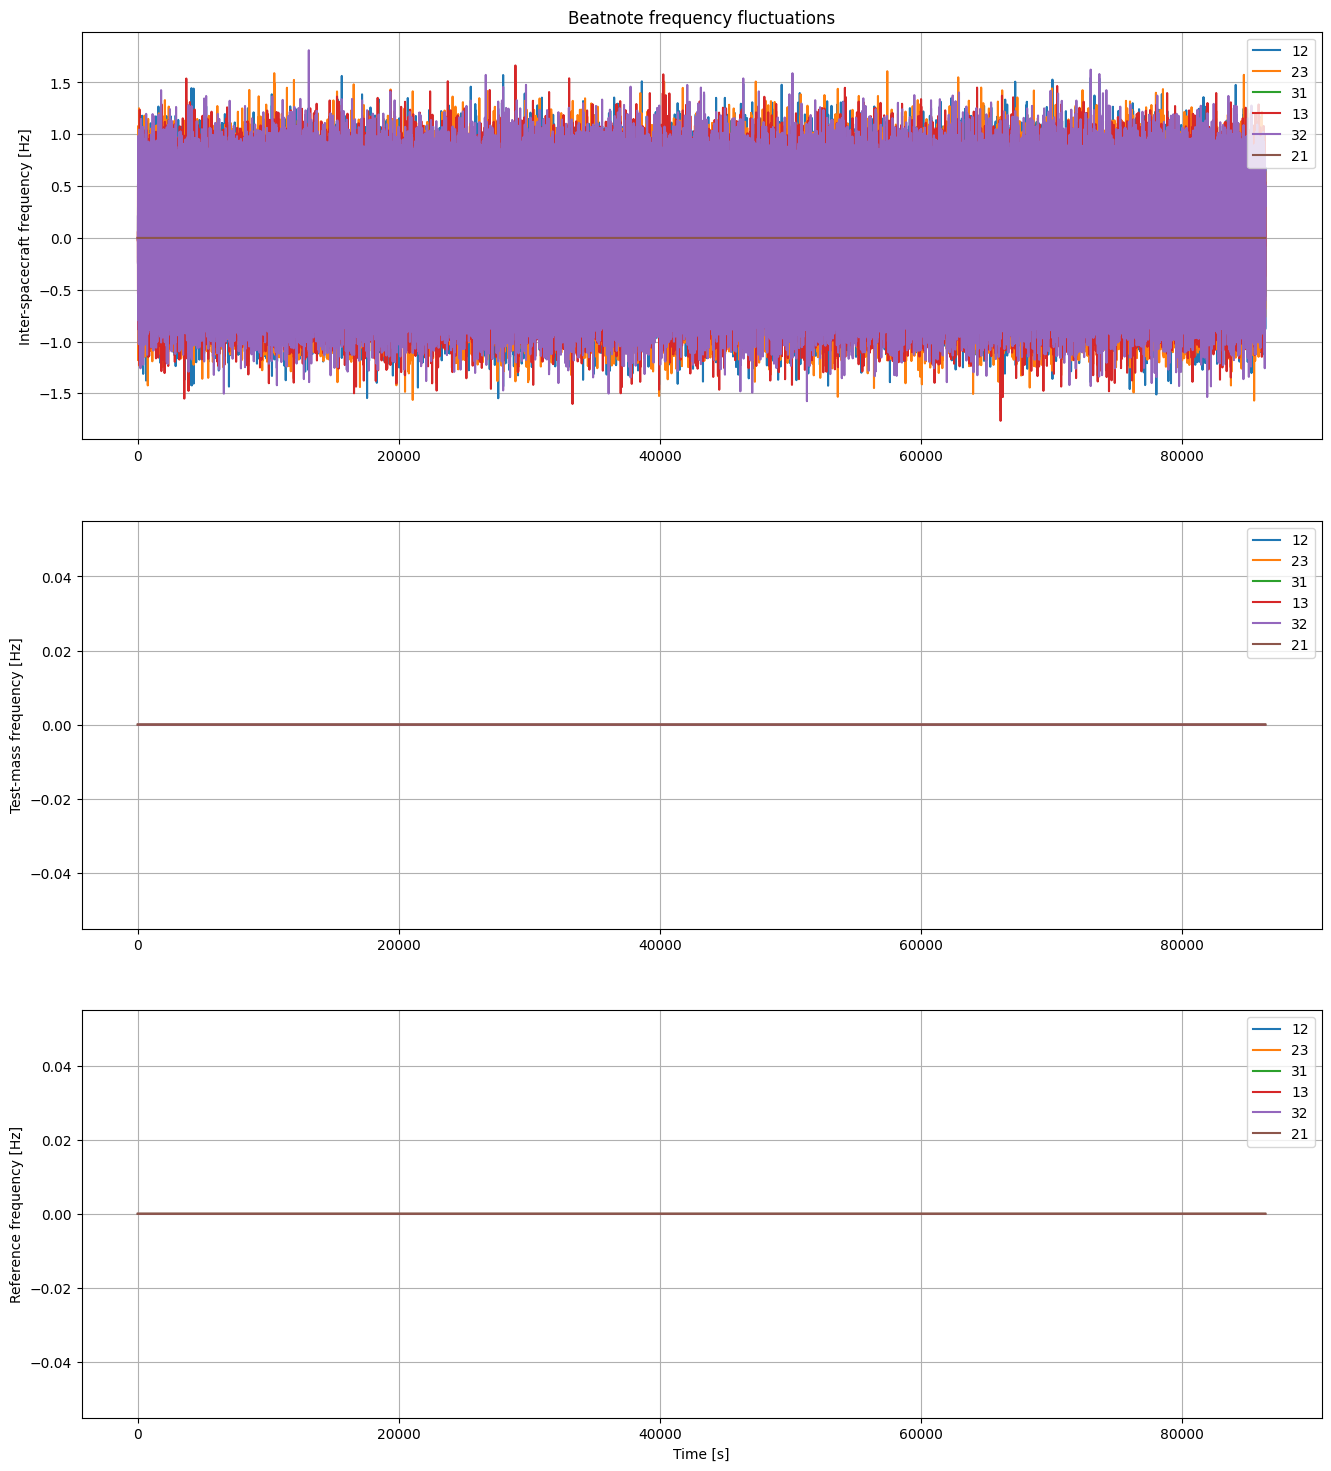

In [43]:
instru.plot_fluctuations()

In [44]:
data = Data.from_instrument(instru)

INFO:pytdi.interface:Loading instrument object '<lisainstrument.instrument.Instrument object at 0x11aa6d1d0>'
INFO:pytdi.interface:Initializing data object
INFO:pytdi.interface:Computing delay derivatives


In [45]:
#Build XYZ TDI channels
'''
noisedata = Data.from_instrument(sim_name)

X_noise = X2.build(**noisedata.args)(noisedata.measurements) / instru.central_freq
Y_noise = Y2.build(**noisedata.args)(noisedata.measurements) / instru.central_freq
Z_noise = Z2.build(**noisedata.args)(noisedata.measurements) / instru.central_freq
'''
simdata = Data.from_instrument(sim_name)

X = X2.build(**simdata.args)(simdata.measurements) / instru.central_freq
Y = Y2.build(**simdata.args)(simdata.measurements) / instru.central_freq
Z = Z2.build(**simdata.args)(simdata.measurements) / instru.central_freq


INFO:pytdi.interface:Loading measurement file 'TTL_only_sim_1.h5'
INFO:pytdi.interface:Initializing data object
INFO:pytdi.interface:Computing delay derivatives
INFO:pytdi.core:Building combination '<pytdi.core.LISATDICombination object at 0x11501b750>'
INFO:pytdi.core:Evaluate combination '<pytdi.core.LISATDICombination object at 0x11501b750>'
INFO:pytdi.core:Building combination '<pytdi.core.LISATDICombination object at 0x11501b050>'
INFO:pytdi.core:Evaluate combination '<pytdi.core.LISATDICombination object at 0x11501b050>'
INFO:pytdi.core:Building combination '<pytdi.core.LISATDICombination object at 0x115032e10>'
INFO:pytdi.core:Evaluate combination '<pytdi.core.LISATDICombination object at 0x115032e10>'


In [46]:
def XYZtoAET(X,Y,Z):
    A = (1/np.sqrt(2))*(Z-X)
    E = (1/np.sqrt(6))*(X-2*Y+Z)
    T = (1/np.sqrt(3))*(Z+X+Y)
    return A,E,T

In [47]:
A,E,T = XYZtoAET(X,Y,Z)

In [48]:
#Build the PSD
skip = 300
f, psd_A2 = scipy.signal.welch(A[skip:],
                               fs=instru.fs,
                               nperseg=len(A[skip:]))
f, psd_E2 = scipy.signal.welch(E[skip:],
                               fs=instru.fs,
                               nperseg=len(E[skip:]))
f, psd_T2 = scipy.signal.welch(T[skip:],
                               fs=instru.fs,
                               nperseg=len(T[skip:]))

In [61]:
#Robbies eyeballed version:
#generate noise psd for 2.3mm/rad
fstar = 0.0190854 #c/L/(2*np.pi)
psd_sqrt = (2e-10*(np.sin(2*f/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
psd = ((6e-11*(np.sin(2*f/fstar)**2) + 1e-12)/2.5e9)**2/((f[1]-f[2])*4)

#Add noise function
def randc(r):
    #fix seed
    np.random.seed(42)
    return r/np.sqrt(2)*(np.random.rand(*r.shape) + 1j*np.random.rand(*r.shape))

def randE(r):
    #fix seed
    np.random.seed(24)
    return r/np.sqrt(2)*(np.random.rand(*r.shape) + 1j*np.random.rand(*r.shape))

#generate noise
noise_fft_A = randc(psd)
noise_fft_E = randE(psd)

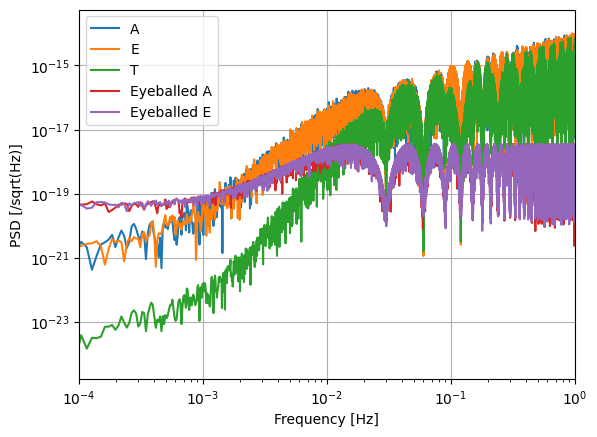

In [63]:
plt.figure()
plt.loglog(f, np.sqrt(psd_A2), label = 'A')
plt.loglog(f, np.sqrt(psd_E2), label = 'E')
plt.loglog(f, np.sqrt(psd_T2), label = 'T')
plt.loglog(f, np.sqrt(np.abs(noise_fft_A)), label = 'Eyeballed A')
plt.loglog(f, np.sqrt(np.abs(noise_fft_E)), label = 'Eyeballed E')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [/sqrt(Hz)]')
plt.legend()
plt.xlim([1e-4, 1]) # restrict frequency band
plt.grid()